# Exploratory Data Analysis: German Credit Dataset

## Objective
Perform a comprehensive Exploratory Data Analysis (EDA) on the German Credit dataset to understand the features, distributions, and relationships with the target variable (credit risk).

## Dataset Source
This dataset is originally from Prof. Dr. Hans Hofmann, Universität Hamburg.

## Environment Setup & Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

# Configure visualization style
%matplotlib inline
sns.set_theme(style="whitegrid")
sns.set_palette("muted")

# Set pandas display options for readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Ensure plot output directory exists
os.makedirs('../results/plots', exist_ok=True)

## Dataset Loading
We load the dataset using `pandas`. The data is space-separated without a header, so we provide the column names explicitly.

In [2]:
column_names = [
    'checking_status', 'duration', 'credit_history', 'purpose', 'credit_amount', 
    'savings_status', 'employment', 'installment_commitment', 'personal_status', 
    'other_parties', 'residence_since', 'property_magnitude', 'age', 
    'other_payment_plans', 'housing', 'existing_credits', 'job', 
    'num_dependents', 'own_telephone', 'foreign_worker', 'target'
]

# Load dataset
df = pd.read_csv('../data/german.data', sep=' ', header=None, names=column_names)

print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


The dataset contains 1000 observations and 21 columns (20 features and 1 target variable). The categorical variables appear to be encoded as alphanumeric strings (e.g., A11, A32), which corresponds to the original dataset's documentation.

## Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exist

The dataset consists of 7 integer columns (including the target) and 14 object (string) columns.

In [4]:
# Check for missing values
df.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
target                    0
dtype: int64

There are **no missing values** in any of the columns, which means we do not need to perform imputation.

In [5]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


There are **no duplicate rows** in the dataset.

In [6]:
# Unique values per column
df.nunique()

checking_status             4
duration                   33
credit_history              5
purpose                    10
credit_amount             921
savings_status              5
employment                  5
installment_commitment      4
personal_status             4
other_parties               3
residence_since             4
property_magnitude          4
age                        53
other_payment_plans         3
housing                     3
existing_credits            4
job                         4
num_dependents              2
own_telephone               2
foreign_worker              2
target                      2
dtype: int64

Features like `credit_amount` and `duration` have many unique values, indicating they are continuous. Most categorical features have between 2 and 10 unique categories.

## Target Analysis
In the raw dataset, the target column uses `1` for Good credit and `2` for Bad credit. For standard machine learning practices, we will convert this to a binary format where `1` represents Good (positive class) and `0` represents Bad (negative class).

In [7]:
# Convert target encoding
df['target'] = df['target'].map({1: 1, 2: 0})

target_counts = df['target'].value_counts()
target_pct = df['target'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({'Count': target_counts, 'Percentage': target_pct})
target_summary.index = ['Good (1)', 'Bad (0)']
target_summary

,Count,Percentage
Good (1),700,70.0
Bad (0),300,30.0


C:\Users\mahes\AppData\Local\Temp\ipykernel_21476\3348776877.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Bad (0)', 'Good (1)'])


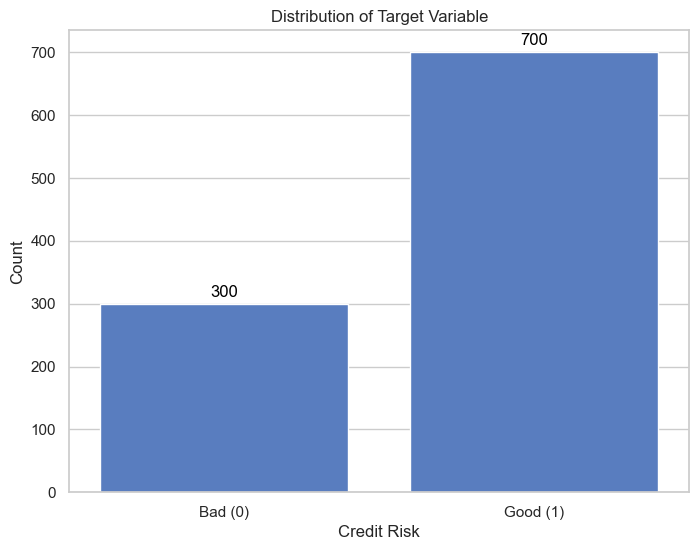

In [8]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(x='target', data=df)
ax.set_xticklabels(['Bad (0)', 'Good (1)'])
plt.title('Distribution of Target Variable')
plt.xlabel('Credit Risk')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.savefig('../results/plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:** The class distribution is moderately imbalanced with 70% Good credit instances and 30% Bad credit instances. While not severely imbalanced, this 70/30 split should be kept in mind during model evaluation (e.g., using precision-recall or F1-score rather than just accuracy).

## Numerical Feature Analysis
There are 7 numerical features in the dataset.

In [9]:
numerical_cols = ['duration', 'credit_amount', 'installment_commitment', 
                  'residence_since', 'age', 'existing_credits', 'num_dependents']

df[numerical_cols].describe()

,duration,credit_amount,installment_commitment,residence_since,age,existing_credits,num_dependents
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


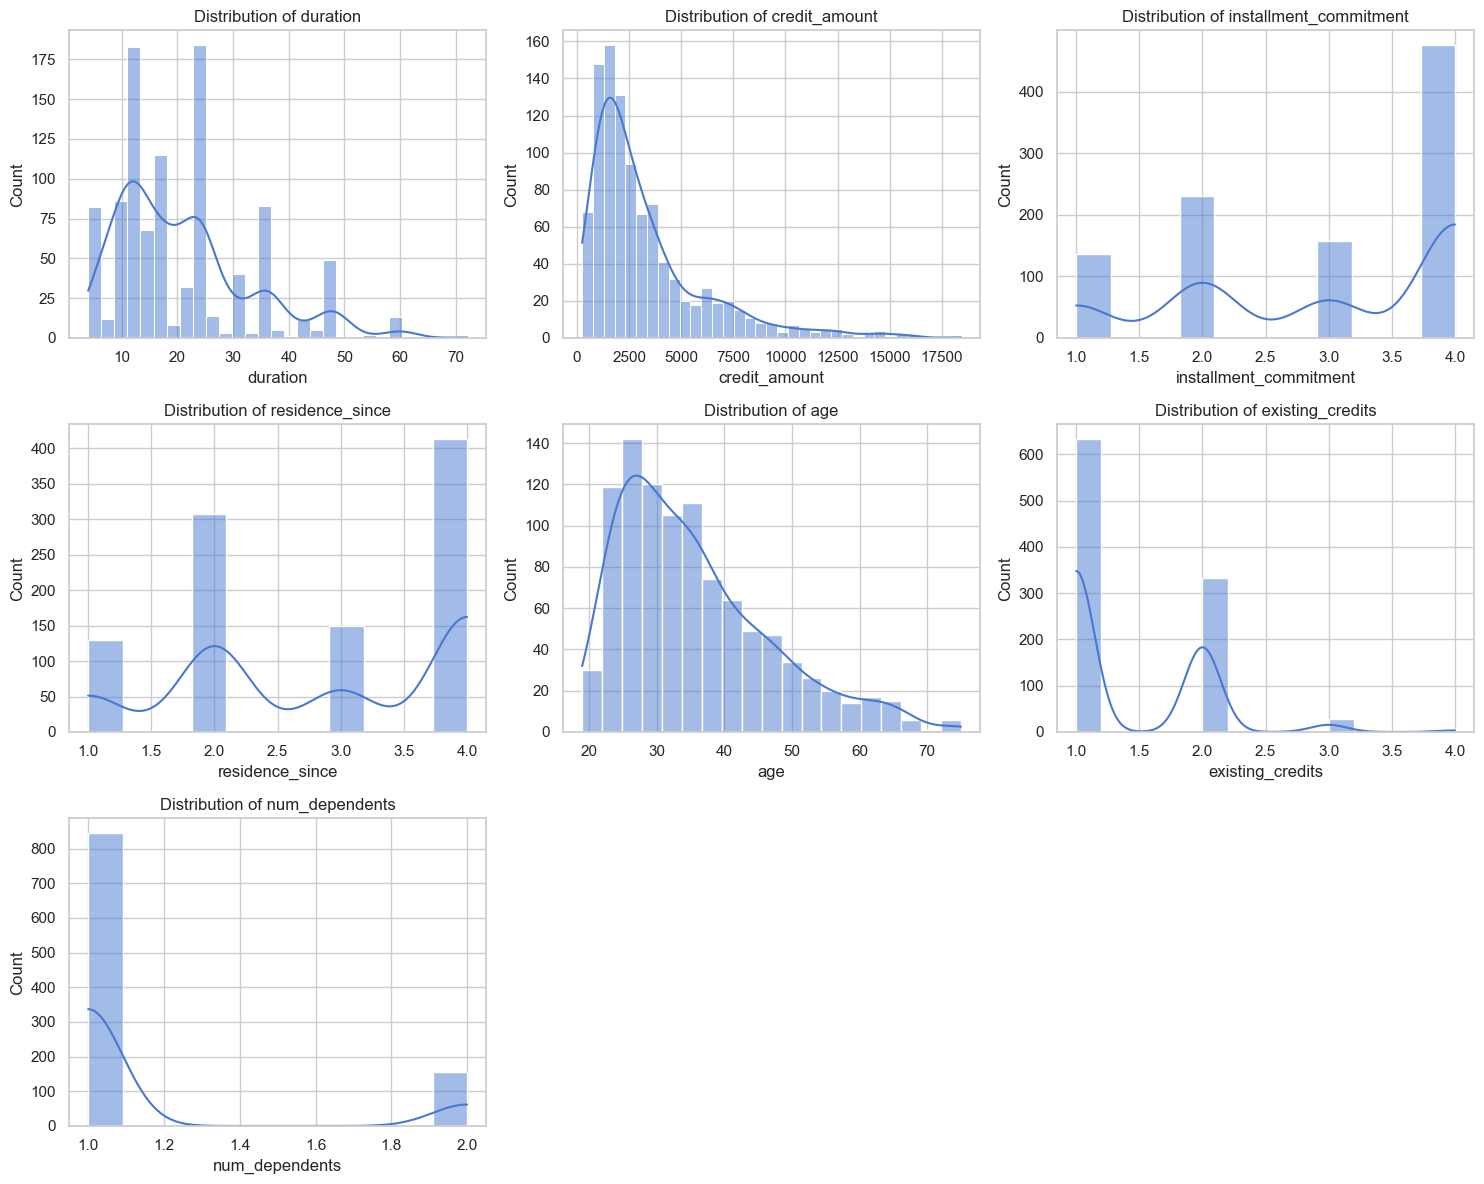

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('../results/plots/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

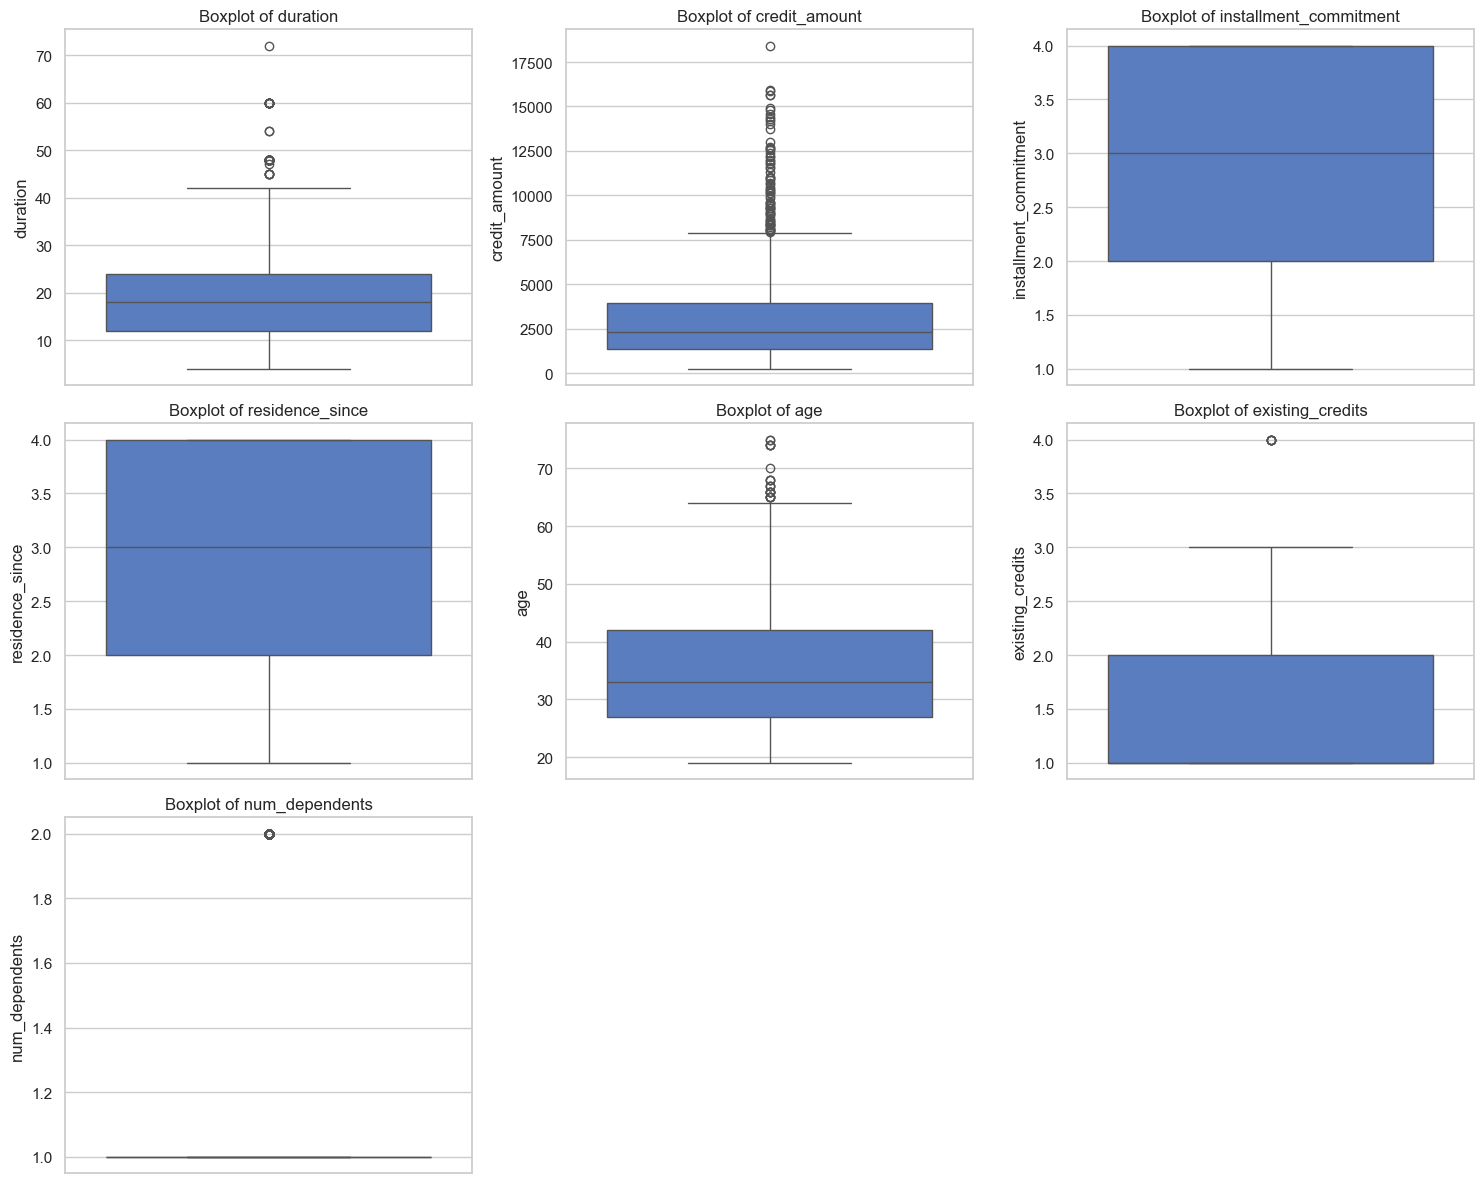

In [11]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

**Interpretation:**
- `credit_amount` is highly right-skewed with significant outliers. Most loans are for smaller amounts, but there are some very large loans.
- `age` is right-skewed, showing that the majority of applicants are younger (between 20 and 40 years old).
- Features like `installment_commitment`, `residence_since`, `existing_credits`, and `num_dependents` behave more like discrete ordinal variables.

## Categorical Feature Analysis
There are 13 categorical features in the dataset.

In [12]:
categorical_cols = [col for col in df.columns if col not in numerical_cols and col != 'target']

print("Categorical feature value counts:\n")
for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print("\n")

Categorical feature value counts:

--- checking_status ---
checking_status
A14    394
A11    274
A12    269
A13     63
Name: count, dtype: int64


--- credit_history ---
credit_history
A32    530
A34    293
A33     88
A31     49
A30     40
Name: count, dtype: int64


--- purpose ---
purpose
A43     280
A40     234
A42     181
A41     103
A49      97
A46      50
A45      22
A44      12
A410     12
A48       9
Name: count, dtype: int64


--- savings_status ---
savings_status
A61    603
A65    183
A62    103
A63     63
A64     48
Name: count, dtype: int64


--- employment ---
employment
A73    339
A75    253
A74    174
A72    172
A71     62
Name: count, dtype: int64


--- personal_status ---
personal_status
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64


--- other_parties ---
other_parties
A101    907
A103     52
A102     41
Name: count, dtype: int64


--- property_magnitude ---
property_magnitude
A123    332
A121    282
A122    232
A124    154
Name: count, dtype: 

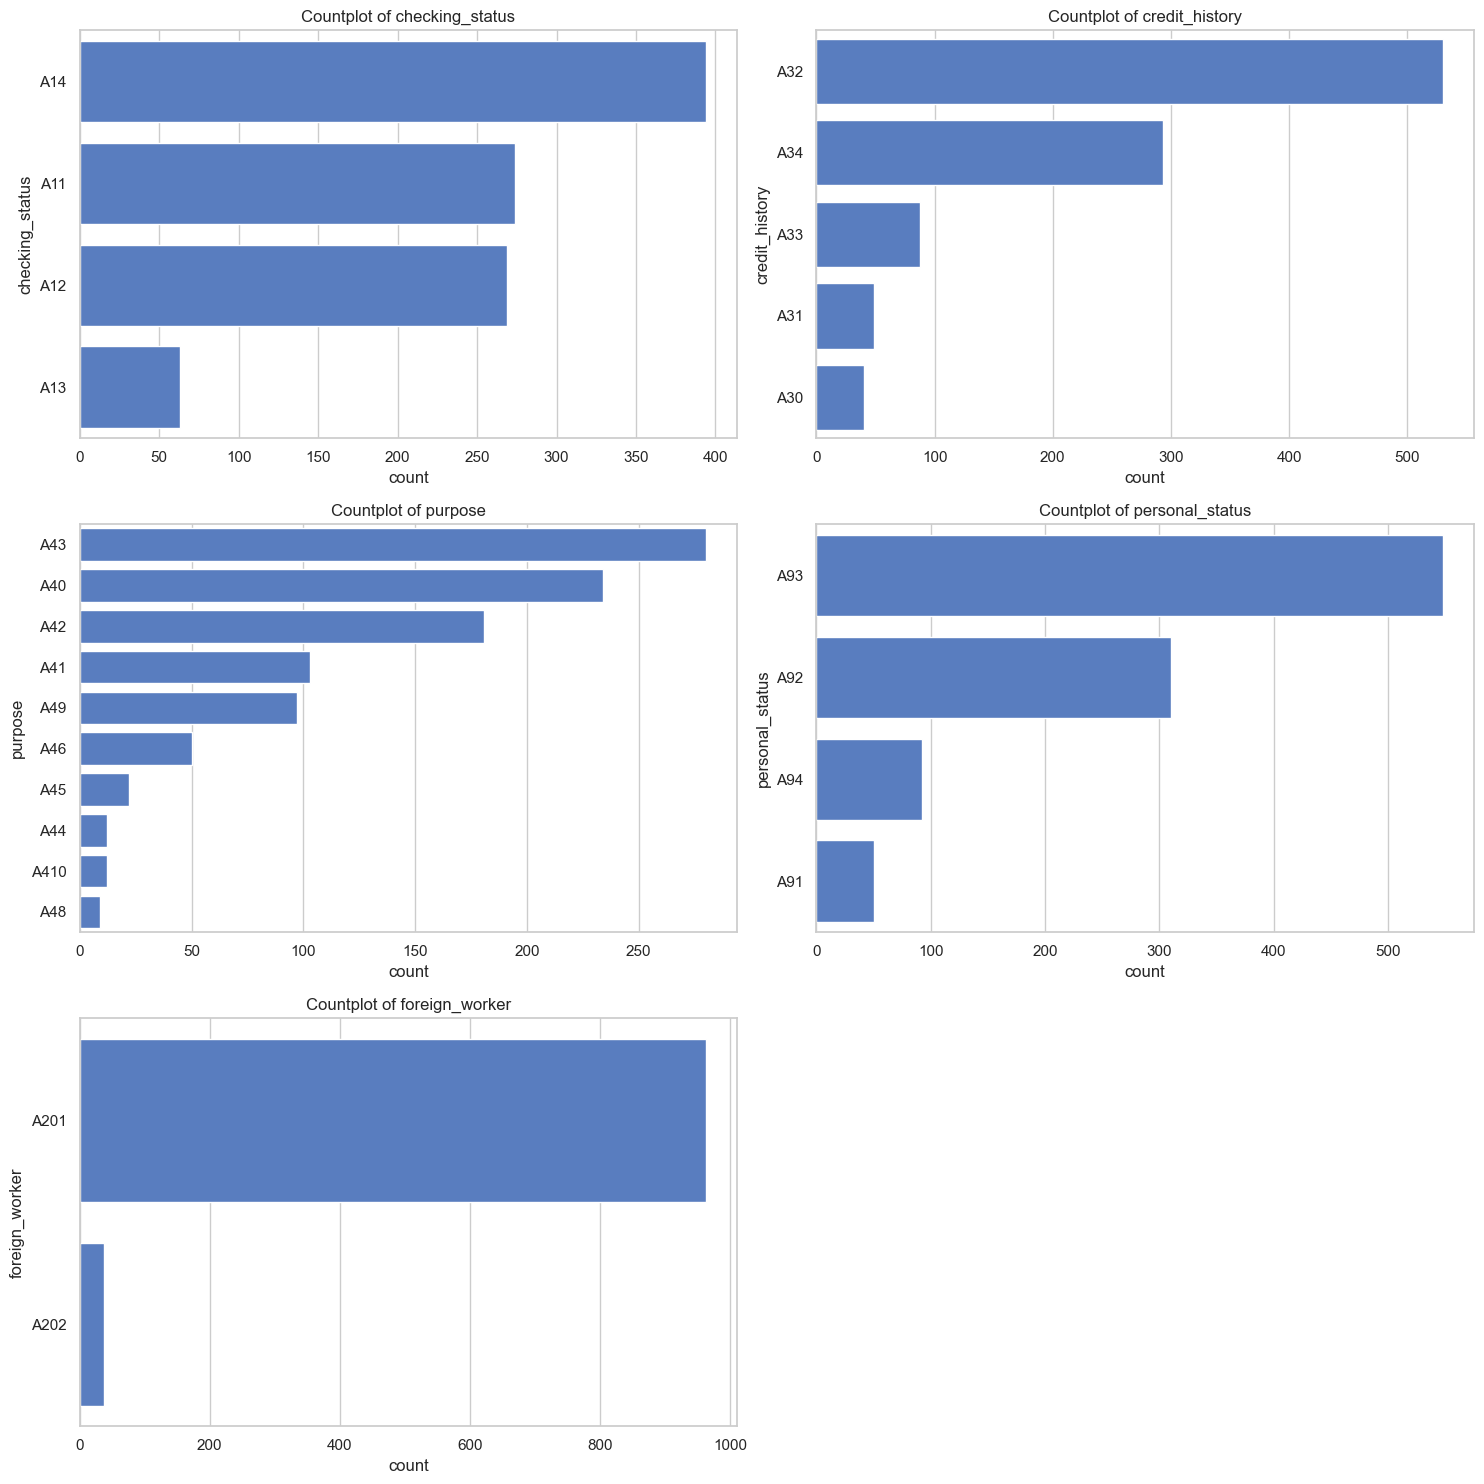

In [13]:
key_categorical_cols = ['checking_status', 'credit_history', 'purpose', 'personal_status', 'foreign_worker']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 15))
axes = axes.flatten()

for i, col in enumerate(key_categorical_cols):
    sns.countplot(y=col, data=df, order=df[col].value_counts().index, ax=axes[i])
    axes[i].set_title(f'Countplot of {col}')

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Interpretation:**
- A large portion of applicants lack a checking account or have negative balances.
- The `purpose` of loans is primarily for radios/TVs and new cars.
- Almost all applicants (963/1000) are foreign workers, representing an extreme imbalance in that specific feature.

## Feature-Target Relationships
We investigate how key features relate to the target variable.

C:\Users\mahes\AppData\Local\Temp\ipykernel_21476\2530567808.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Bad', 'Good'])
C:\Users\mahes\AppData\Local\Temp\ipykernel_21476\2530567808.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Bad', 'Good'])


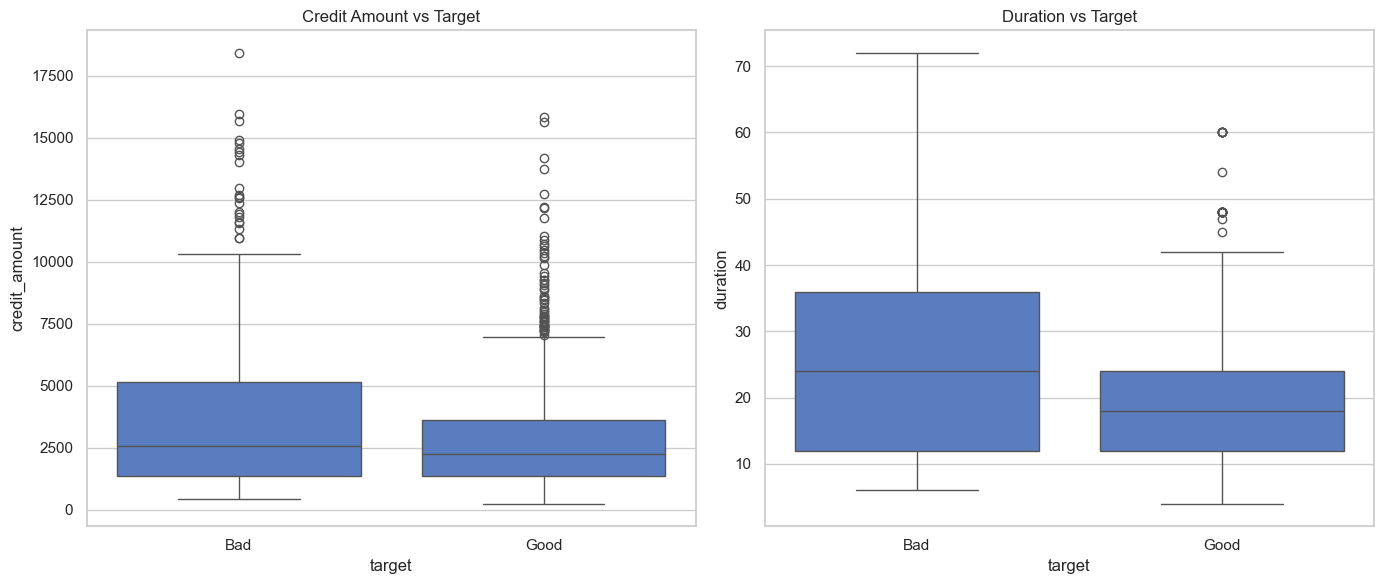

In [14]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

sns.boxplot(x='target', y='credit_amount', data=df, ax=axes[0])
axes[0].set_title('Credit Amount vs Target')
axes[0].set_xticklabels(['Bad', 'Good'])

sns.boxplot(x='target', y='duration', data=df, ax=axes[1])
axes[1].set_title('Duration vs Target')
axes[1].set_xticklabels(['Bad', 'Good'])

plt.tight_layout()
plt.show()

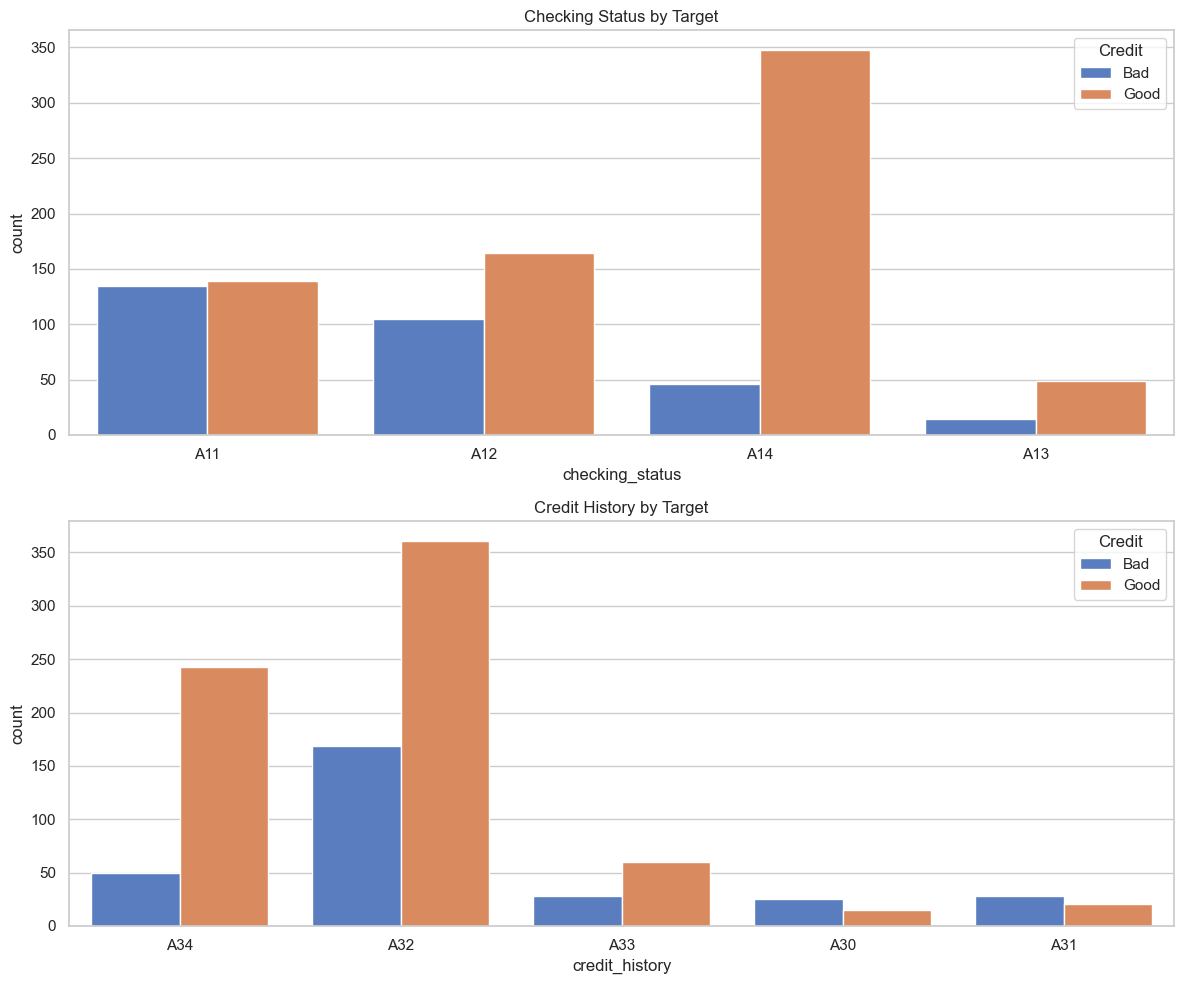

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

# Checking status
sns.countplot(x='checking_status', hue='target', data=df, ax=axes[0])
axes[0].set_title('Checking Status by Target')
axes[0].legend(title='Credit', labels=['Bad', 'Good'])

# Credit history
sns.countplot(x='credit_history', hue='target', data=df, ax=axes[1])
axes[1].set_title('Credit History by Target')
axes[1].legend(title='Credit', labels=['Bad', 'Good'])

plt.tight_layout()
plt.show()

**Interpretation:**
- `duration`: Bad credit loans tend to have slightly longer durations.
- `checking_status`: This seems highly predictive. Individuals with no checking account (A14) have a much higher rate of Good credit.
- `credit_history`: Those who delayed paying off past loans (A34) surprisingly also have higher Good credit rates, possibly because they have a longer established record overall.

## Correlation Analysis
We use Pearson correlation for numerical variables to find linear relationships. Note that Pearson correlation is only meaningful for numerical features, so we exclude categorical columns.

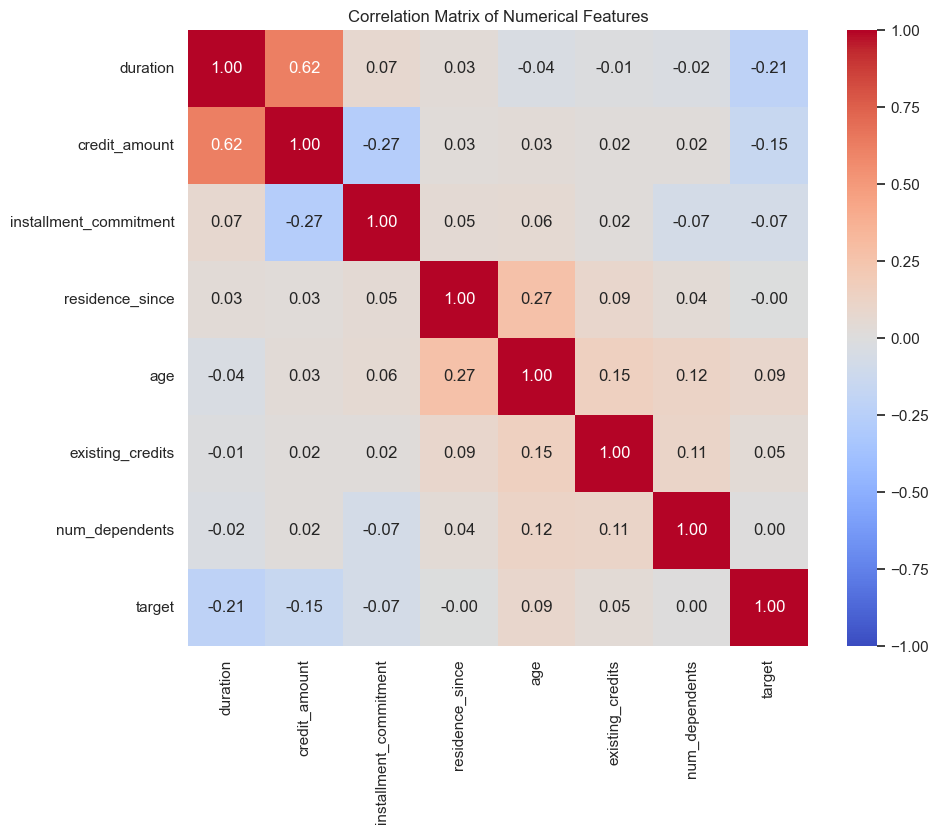

In [16]:
corr_matrix = df[numerical_cols + ['target']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.savefig('../results/plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretation:**
- There is a strong positive correlation (0.62) between `duration` and `credit_amount`, which makes logical sense (larger loans take longer to pay off).
- `target` has weak linear correlations with the numerical features. The strongest are with `duration` (-0.21, longer duration is slightly associated with Bad credit) and `age` (0.09, older age is slightly associated with Good credit).
- Categorical features are likely to hold more predictive power, as seen in the previous section.

## Key Observations
- **Dataset size**: 1000 observations and 20 predictive features.
- **Target distribution**: Moderately imbalanced with ~70% Good credit and ~30% Bad credit cases.
- **Missing values**: The dataset is perfectly complete with 0 missing values.
- **Important feature characteristics**: `credit_amount` is heavily right-skewed. `checking_status` appears to be a strong predictive feature.
- **Protected/sensitive attributes**: Features like `personal_status` (which encodes sex/marital status), `age`, and `foreign_worker` are present. These must be treated carefully in modeling to prevent biased predictions.
- **Potential preprocessing requirements**: Significant skewness in `credit_amount` and `age` may require transformations (e.g., log transform) depending on the model chosen. Categorical variables require encoding (e.g., One-Hot Encoding).